# Effet causal et prévision temporelle

Deux expériences synthétiques indépendantes : confusion mesurée, puis prévision à un pas. Objectifs : identifier une hypothèse causale et vérifier la disponibilité temporelle des features. Dépendances : NumPy, Pandas, Matplotlib, scikit-learn.

## 1. Simulation causale

X précède le traitement T et influence T et Y. L’effet injecté de T vaut 2. On compare association brute et régression ajustée, sous un modèle correctement spécifié.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
rng = np.random.default_rng(42)
x = rng.normal(size=6000)
propensity = 1/(1+np.exp(-x))
treatment = rng.binomial(1, propensity)
outcome = 2*treatment + 3*x + rng.normal(size=len(x))
naive = outcome[treatment==1].mean()-outcome[treatment==0].mean()
adjusted = LinearRegression().fit(np.column_stack([treatment,x]), outcome).coef_[0]
assert abs(adjusted-2) < .2
assert abs(naive-2) > abs(adjusted-2)
print(pd.Series({'effet injecté': 2., 'différence brute': naive, 'ajustement sur X': adjusted}))

effet injecté       2.000000
différence brute    4.431384
ajustement sur X    1.986033
dtype: float64


## 2. Incertitude par bootstrap

Les unités sont indépendantes dans cette simulation. L’intervalle quantifie la variabilité de cet estimateur ; il ne teste pas l’absence de confusion cachée.

Intervalle bootstrap 95 % : [1.92702152 2.04209542]


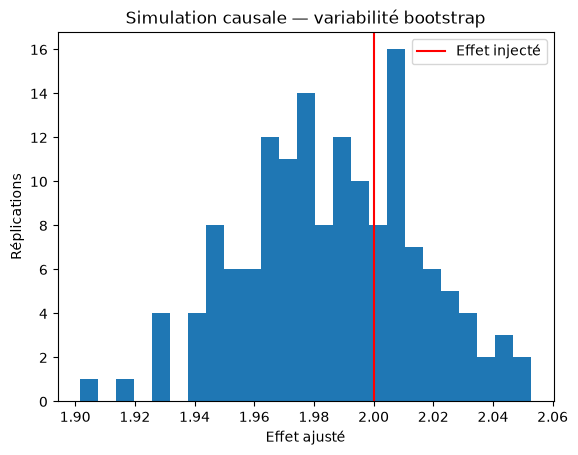

In [2]:
boot = []
for _ in range(150):
    ids = rng.integers(0, len(x), len(x))
    boot.append(LinearRegression().fit(np.column_stack([treatment[ids],x[ids]]), outcome[ids]).coef_[0])
interval = np.quantile(boot, [.025,.975])
print('Intervalle bootstrap 95 % :', interval)
plt.hist(boot, bins=25)
plt.axvline(2, color='red', label='Effet injecté')
plt.xlabel('Effet ajusté'); plt.ylabel('Réplications'); plt.title('Simulation causale — variabilité bootstrap'); plt.legend(); plt.show()

## 3. Série et caractéristiques disponibles

La cible est y(t). Les retards 1 et 7 sont connus au moment de prévoir t. Le calendrier futur est connu. Toutes les features sont construites avant le split mais sans lire le futur.

In [3]:
dates = np.arange(500)
series = 10 + .015*dates + 2*np.sin(2*np.pi*dates/7) + rng.normal(0,.35,len(dates))
frame = pd.DataFrame({'target':series, 'time':dates})
frame['lag1'] = frame.target.shift(1)
frame['lag7'] = frame.target.shift(7)
frame['sin7'] = np.sin(2*np.pi*dates/7)
frame['cos7'] = np.cos(2*np.pi*dates/7)
frame = frame.dropna()
features = ['time','lag1','lag7','sin7','cos7']
assert frame.loc[20,'lag7'] == series[13]

## 4. Validation à origines croissantes

Les blocs de validation se terminent avant la période test (t≥400). Le modèle est réajusté par bloc. On prévoit un pas à la fois : les observations intermédiaires sont donc disponibles.

In [4]:
scores = []
for boundary in [250,300,350]:
    train = frame[frame.time < boundary]
    valid = frame[(frame.time >= boundary) & (frame.time < boundary+40)]
    model = make_pipeline(StandardScaler(), Ridge(alpha=1)).fit(train[features], train.target)
    for name,pred in [('Ridge',model.predict(valid[features])),('naïf',valid.lag1),('saisonnier',valid.lag7)]:
        scores.append({'origine':boundary,'modèle':name,'MAE':mean_absolute_error(valid.target,pred)})
print(pd.DataFrame(scores).pivot(index='origine',columns='modèle',values='MAE'))

modèle      Ridge      naïf  saisonnier
origine                                
250      0.273684  1.095137    0.418419
300      0.298726  1.272832    0.417015
350      0.303325  1.180705    0.334967


## 5. Test terminal

Le protocole et les hyperparamètres sont figés. MASE utilise uniquement le train pour sa normalisation. La figure montre le test, pas l’ajustement au train.

{'MAE Ridge': 0.255501296940691, 'MASE Ridge': np.float64(0.6558942296508812), 'MAE saisonnier': 0.35618985440384365}


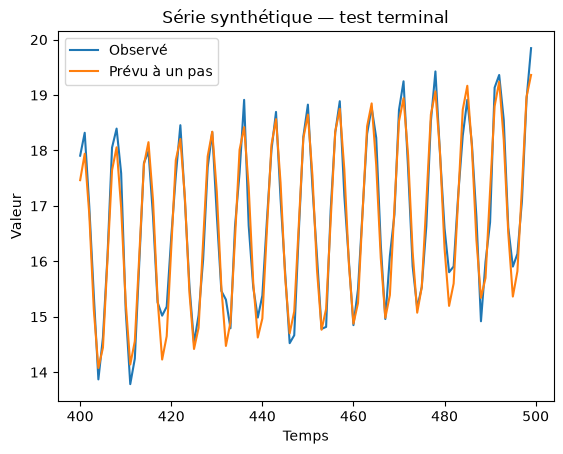

In [5]:
train, test = frame[frame.time < 400], frame[frame.time >= 400]
model = make_pipeline(StandardScaler(), Ridge(alpha=1)).fit(train[features],train.target)
pred = model.predict(test[features])
scale = np.mean(np.abs(train.target-train.lag7))
assert train.time.max() < test.time.min() and scale > 0
print({'MAE Ridge':mean_absolute_error(test.target,pred), 'MASE Ridge':mean_absolute_error(test.target,pred)/scale,
       'MAE saisonnier':mean_absolute_error(test.target,test.lag7)})
plt.plot(test.time,test.target,label='Observé'); plt.plot(test.time,pred,label='Prévu à un pas')
plt.title('Série synthétique — test terminal'); plt.xlabel('Temps'); plt.ylabel('Valeur'); plt.legend(); plt.show()

## Exercice

Retirez X du modèle causal. Pour la prévision, expliquez pourquoi fournir lag1 observé à tous les pas ne convient pas à une prévision de 100 pas émise une seule fois.

In [6]:
# Écrivez votre expérience ici avant de lire la correction.

## Correction et limites

Sans X, la différence brute mélange sélection et effet causal. Pour 100 pas émis en t, y(t+1) est encore inconnu ; utiliser sa vraie valeur pour prévoir t+2 fuit. Il faut une stratégie récursive ou directe et un backtest correspondant à cet horizon.